# Neural Networks from Scratch: XOR

**Learning objectives**
- See why a linear model cannot solve XOR
- Implement forward propagation, binary cross-entropy loss, and backpropagation in NumPy
- Visualize decision boundaries and gradients
- Compare manual gradients with PyTorch autograd

Run cells top-to-bottom. Constants are grouped near the top so you can experiment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Hyperparameters (tweak these) ---
HIDDEN_SIZE = 4
LEARNING_RATE = 0.5
EPOCHS = 8000
PLOT_EVERY = 500

## 1. Problem setup

The XOR function is **not linearly separable**: no single straight line can separate the two classes.

| $x_1$ | $x_2$ | $y$ |
|------|------|-----|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

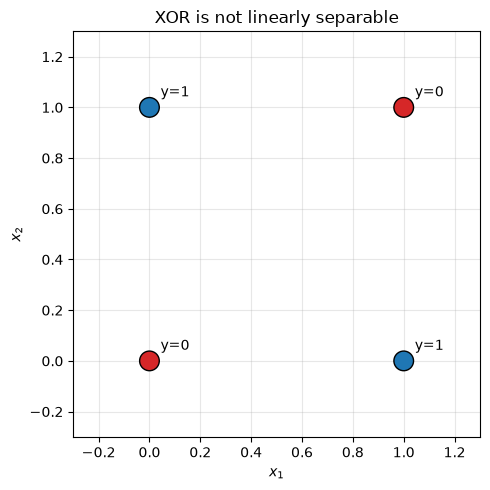

In [2]:
# XOR dataset: 4 samples, 2 features
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)
Y = np.array([[0], [1], [1], [0]], dtype=np.float64)
m = X.shape[0]

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['tab:red' if y == 0 else 'tab:blue' for y in Y.ravel()]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='k', zorder=3)
for (x1, x2), y in zip(X, Y):
    ax.annotate(f'y={int(y.item())}', (x1, x2), textcoords='offset points', xytext=(8, 8))
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('XOR is not linearly separable')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

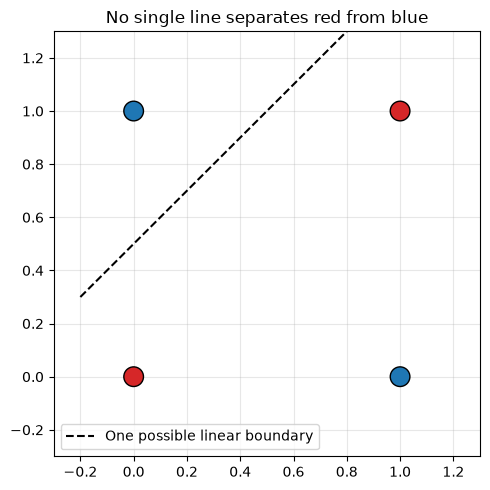

In [3]:
# A single linear classifier: y_hat = step(w·x + b) cannot fit XOR.
# Draw one arbitrary line to show the failure mode.
w_line = np.array([1.0, -1.0])
b_line = 0.5
x_grid = np.linspace(-0.2, 1.2, 100)
# w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b)/w2
y_boundary = -(w_line[0] * x_grid + b_line) / w_line[1]

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['tab:red' if y == 0 else 'tab:blue' for y in Y.ravel()]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='k', zorder=3)
ax.plot(x_grid, y_boundary, 'k--', label='One possible linear boundary')
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.legend()
ax.set_title('No single line separates red from blue')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Architecture

We use a **2-layer network** with a hidden layer to introduce non-linearity:

```
Input (2)  →  Hidden (4, sigmoid)  →  Output (1, sigmoid)
```

Notation (for one sample, row vector $x$):
- $Z^{[1]} = x W^{[1]} + b^{[1]}$, $A^{[1]} = \sigma(Z^{[1]})$
- $Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]}$, $\hat{y} = A^{[2]} = \sigma(Z^{[2]})$

Weight shapes (NumPy row-vector convention):
- $W^{[1]}$: `(2, 4)`, $b^{[1]}$: `(1, 4)`
- $W^{[2]}$: `(4, 1)`, $b^{[2]}$: `(1, 1)`

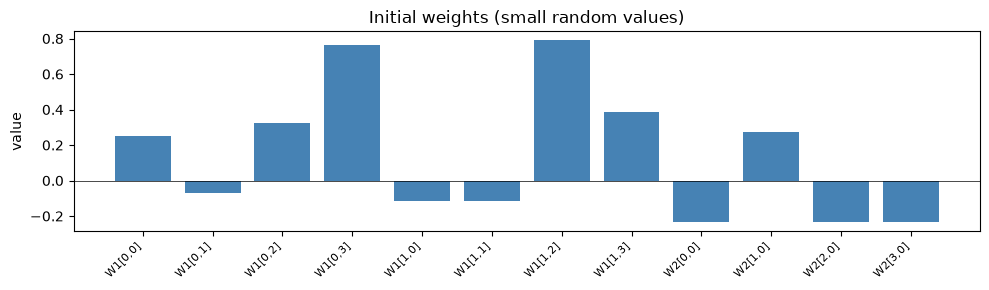

In [4]:
def sigmoid(Z):
    return 1.0 / (1.0 + np.exp(-Z))

def init_params(n_x=2, n_h=HIDDEN_SIZE, n_y=1):
    # Small random init breaks symmetry
    W1 = np.random.randn(n_x, n_h) * 0.5
    b1 = np.zeros((1, n_h))
    W2 = np.random.randn(n_h, n_y) * 0.5
    b2 = np.zeros((1, n_y))
    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params()

labels = [f'W1[{i},{j}]' for i in range(W1.shape[0]) for j in range(W1.shape[1])]
labels += [f'W2[{i},0]' for i in range(W2.shape[0])]
values = np.concatenate([W1.ravel(), W2.ravel()])

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(values)), values, color='steelblue')
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('value')
ax.set_title('Initial weights (small random values)')
ax.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

## 3. Forward propagation

Forward pass = compute predictions by flowing data left-to-right through the network.

For **all 4 samples at once** (matrix $X$ has shape `(m, 2)`):

$$Z^{[1]} = X W^{[1]} + b^{[1]} \quad (m \times 4)$$
$$A^{[1]} = \sigma(Z^{[1]})$$
$$Z^{[2]} = A^{[1]} W^{[2]} + b^{[2]} \quad (m \times 1)$$
$$A^{[2]} = \sigma(Z^{[2]}) = \hat{Y}$$

In [5]:
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

A2, cache = forward(X, W1, b1, W2, b2)
X_c, Z1, A1, Z2, A2 = cache

print('Shapes:')
print(f'  X: {X.shape}, Z1: {Z1.shape}, A1: {A1.shape}, Z2: {Z2.shape}, A2: {A2.shape}')
print('\nPredictions before training (rounded):')
for i in range(m):
    print(f'  x={X[i]}  y={int(Y[i,0])}  y_hat={A2[i,0]:.4f}  round={int(A2[i,0] >= 0.5)}')

Shapes:
  X: (4, 2), Z1: (4, 4), A1: (4, 4), Z2: (4, 1), A2: (4, 1)

Predictions before training (rounded):
  x=[0. 0.]  y=0  y_hat=0.4467  round=0
  x=[0. 1.]  y=1  y_hat=0.4303  round=0
  x=[1. 0.]  y=1  y_hat=0.4270  round=0
  x=[1. 1.]  y=0  y_hat=0.4126  round=0


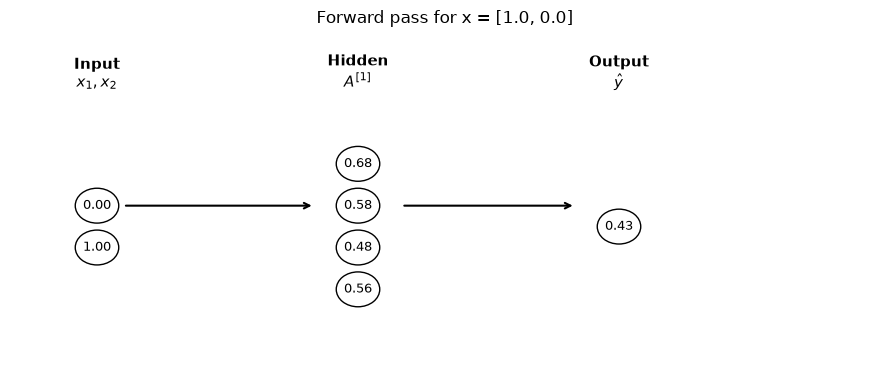

In [6]:
# Visualize one forward pass on sample x = [1, 0]
idx = 2
x_sample = X[idx:idx+1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.set_title(f'Forward pass for x = {X[idx].tolist()}')

layers = [
    ('Input\n$x_1, x_2$', 1, 2.5, x_sample[0]),
    ('Hidden\n$A^{[1]}$', 4, 2.5, A1[idx]),
    ('Output\n$\\hat{y}$', 7, 2.5, A2[idx:idx+1]),
]
for name, xpos, ypos, vals in layers:
    ax.text(xpos, 4.2, name, ha='center', fontsize=11, fontweight='bold')
    for j, v in enumerate(np.ravel(vals)):
        ax.add_patch(plt.Circle((xpos, ypos + (j - len(np.ravel(vals))/2) * 0.6), 0.25, fill=False))
        ax.text(xpos, ypos + (j - len(np.ravel(vals))/2) * 0.6, f'{float(v):.2f}', ha='center', va='center', fontsize=9)

for x_start, x_end in [(1.3, 3.5), (4.5, 6.5)]:
    ax.annotate('', xy=(x_end, 2.5), xytext=(x_start, 2.5),
                arrowprops=dict(arrowstyle='->', lw=1.5))
plt.tight_layout()
plt.show()

### Pause & Reflect — Forward propagation

1. Why do we apply sigmoid **twice** (hidden and output) instead of only at the output?
2. What does the shape `(m, 4)` for $A^{[1]}$ tell you about how many hidden neurons fired?
3. If $W^{[1]}$ were all zeros, what would $A^{[1]}$ be after sigmoid? Would learning be possible?

### Discussion — Forward propagation

1. **Double sigmoid**: The hidden sigmoid introduces **non-linearity** — without it, stacking linear layers collapses to one linear map. The output sigmoid squashes to $(0,1)$ for probabilistic interpretation.
2. **Shape `(m, 4)`**: Each of the 4 hidden neurons produces one activation per sample; column $j$ is neuron $j$'s response across the batch.
3. **Zero weights**: $Z^{[1]} = 0$, so $A^{[1]} = 0.5$ everywhere — all hidden units identical (**symmetry**). Random init breaks this so neurons can specialize.

## 4. Cost function (binary cross-entropy)

We measure how wrong predictions are with **binary cross-entropy** (BCE):

$$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

- When $y=1$, we penalize $-\log(\hat{y})$ — pushes $\hat{y} \to 1$
- When $y=0$, we penalize $-\log(1-\hat{y})$ — pushes $\hat{y} \to 0$

We clip $\hat{y}$ slightly inside $(0,1)$ to avoid $\log(0)$.

Average loss before training: 0.7046


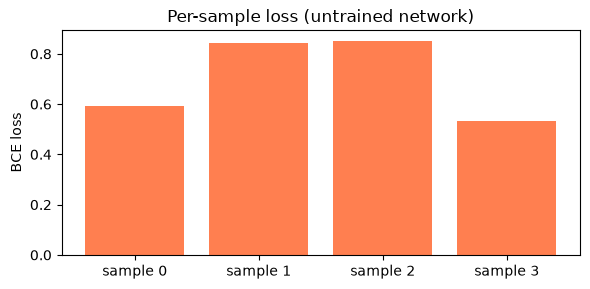

In [11]:
def compute_loss(Y, A2):
    eps = 1e-8
    A2_clip = np.clip(A2, eps, 1 - eps)
    per_sample = -(Y * np.log(A2_clip) + (1 - Y) * np.log(1 - A2_clip))
    return float(np.mean(per_sample)), per_sample

loss, per_sample_loss = compute_loss(Y, A2)
print(f'Average loss before training: {loss:.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([f'sample {i}' for i in range(m)], per_sample_loss.ravel(), color='coral')
ax.set_ylabel('BCE loss')
ax.set_title('Per-sample loss (untrained network)')
plt.tight_layout()
plt.show()

### Pause & Reflect — Cost function

1. What happens to BCE when $\hat{y} = 0.5$ for every sample?
2. Why is MSE (mean squared error) less ideal than BCE for classification?
3. If $\hat{y} = 0.99$ when $y = 1$, is the gradient large or small?

### Discussion — Cost function

1. **$\hat{y}=0.5$**: BCE $= -\log(0.5) \approx 0.69$ per sample — high uncertainty, substantial gradient signal.
2. **BCE vs MSE**: BCE penalizes confident wrong answers much more sharply; its gradient with sigmoid often behaves better for classification.
3. **$\hat{y}=0.99, y=1$**: Loss is small ($\approx 0.01$), so gradient is **small** — the network is already nearly correct for that sample.

## 5. Backpropagation

Backprop applies the **chain rule** backward from loss to every weight.

### Output layer (sigmoid + BCE)

For one sample, with $\delta^{[2]} = \frac{\partial L}{\partial Z^{[2]}}$:

$$\delta^{[2]} = A^{[2]} - Y$$

This elegant shortcut comes from pairing sigmoid with BCE — the sigmoid derivative cancels messy terms.

### Hidden layer

$$\delta^{[1]} = (\delta^{[2]} W^{[2]T}) \odot \sigma'(Z^{[1]})$$
$$\sigma'(z) = \sigma(z)(1 - \sigma(z)) = A^{[1]}(1 - A^{[1]})$$

### Gradients (batch average)

$$\frac{\partial L}{\partial W^{[2]}} = \frac{1}{m} A^{[1]T} \delta^{[2]}, \quad \frac{\partial L}{\partial b^{[2]}} = \frac{1}{m} \sum \delta^{[2]}$$
$$\frac{\partial L}{\partial W^{[1]}} = \frac{1}{m} X^T \delta^{[1]}, \quad \frac{\partial L}{\partial b^{[1]}} = \frac{1}{m} \sum \delta^{[1]}$$

In [12]:
def backward(X, Y, cache, W2):
    m = X.shape[0]
    _, Z1, A1, Z2, A2 = cache

    # Output layer
    dZ2 = A2 - Y                          # (m, 1)
    dW2 = (A1.T @ dZ2) / m                # (4, 1)
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer
    dA1 = dZ2 @ W2.T                      # (m, 4)
    dZ1 = dA1 * (A1 * (1 - A1))           # sigmoid derivative
    dW1 = (X.T @ dZ1) / m                 # (2, 4)
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

grads = backward(X, Y, cache, W2)
dW1, db1, dW2, db2 = grads
print('Gradient shapes:', dW1.shape, db1.shape, dW2.shape, db2.shape)

Gradient shapes: (2, 4) (1, 4) (4, 1) (1, 1)


/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_7711/1055290761.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


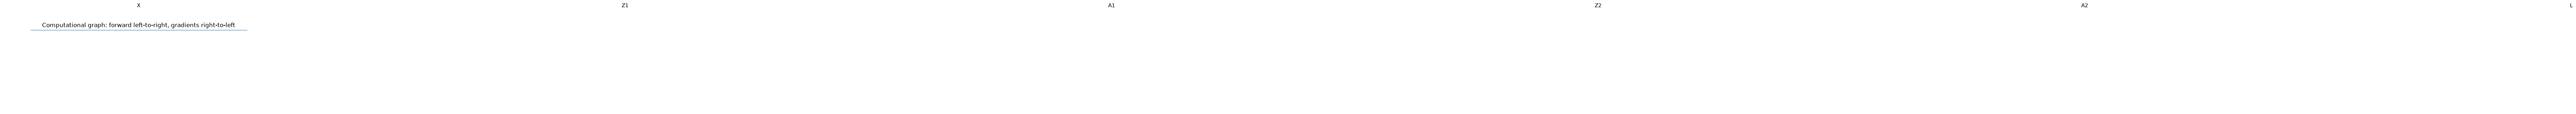

In [17]:
# Computational graph (conceptual)
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
nodes = ['X', 'Z1', 'A1', 'Z2', 'A2', 'L']
xs = np.linspace(0.5, 9.5, len(nodes))
for x, n in zip(xs, nodes):
    ax.add_patch(plt.Rectangle((x - 0.4, 1), 0.8, 0.6, fill=False, ec='steelblue'))
    ax.text(x, 1.3, n, ha='center', va='center', fontsize=11)
for i in range(len(nodes) - 1):
    ax.annotate('', xy=(xs[i+1] - 0.45, 1.3), xytext=(xs[i] + 0.45, 1.3),
                arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('forward →', xy=(5, 0.4), fontsize=10, ha='center')
ax.annotate('← gradients flow backward', xy=(5, 2.1), fontsize=10, ha='center', color='crimson')
ax.set_title('Computational graph: forward left-to-right, gradients right-to-left')
plt.tight_layout()
plt.show()

In [10]:
# Gradient magnitudes per parameter group
groups = ['dW1', 'db1', 'dW2', 'db2']
magnitudes = [np.linalg.norm(dW1), np.linalg.norm(db1), np.linalg.norm(dW2), np.linalg.norm(db2)]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(groups, magnitudes, color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])
ax.set_ylabel('L2 norm')
ax.set_title('Gradient magnitude by parameter tensor')
plt.tight_layout()
plt.show()

/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_90025/552890057.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [11]:
# One gradient step: weights before vs after
W1_before, W2_before = W1.copy(), W2.copy()
dW1, db1, dW2, db2 = backward(X, Y, cache, W2)
W1_step = W1 - LEARNING_RATE * dW1
W2_step = W2 - LEARNING_RATE * dW2

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, name, before, after in [
    (axes[0], 'W1', W1_before.ravel(), W1_step.ravel()),
    (axes[1], 'W2', W2_before.ravel(), W2_step.ravel()),
]:
    x = np.arange(len(before))
    ax.bar(x - 0.15, before, width=0.3, label='before')
    ax.bar(x + 0.15, after, width=0.3, label='after 1 step')
    ax.set_title(name)
    ax.legend()
plt.suptitle('Effect of one gradient descent step')
plt.tight_layout()
plt.show()

/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_90025/2780095448.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Pause & Reflect — Backpropagation

1. Why does $\delta^{[2]} = A^{[2]} - Y$ simplify the math? What would change with MSE + sigmoid?
2. What role does $\sigma'(Z^{[1]})$ play when the hidden unit is saturated ($A^{[1]} \approx 0$ or $1$)?
3. Why do we divide gradients by $m$?

### Discussion — Backpropagation

1. **$\delta^{[2]} = A^{[2]} - Y$**: With BCE+sigmoid, the derivative of loss w.r.t. $Z^{[2]}$ reduces to prediction error — same form as linear regression!
2. **Saturated sigmoid**: $\sigma' \approx 0$, so gradient **vanishes** through that neuron — it stops learning (vanishing gradient problem).
3. **Divide by $m$**: Averages the gradient over the batch so learning rate meaning stays stable as batch size changes.

## 6. Training loop

**Gradient descent** update rule:

$$W \leftarrow W - \alpha \frac{\partial L}{\partial W}$$

We use full-batch GD (all 4 XOR points every epoch).

In [12]:
def predict(X, W1, b1, W2, b2):
    A2, _ = forward(X, W1, b1, W2, b2)
    return (A2 >= 0.5).astype(int)

def train(X, Y, epochs=EPOCHS, lr=LEARNING_RATE):
    W1, b1, W2, b2 = init_params()
    losses = []
    history_weights = []

    for epoch in range(epochs + 1):
        A2, cache = forward(X, W1, b1, W2, b2)
        loss, _ = compute_loss(Y, A2)
        losses.append(loss)
        if epoch % PLOT_EVERY == 0:
            history_weights.append((epoch, W1.copy(), W2.copy(), b1.copy(), b2.copy()))
        if epoch == epochs:
            break
        dW1, db1, dW2, db2 = backward(X, Y, cache, W2)
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2, losses, history_weights

W1, b1, W2, b2, losses, history_weights = train(X, Y)
final_A2, _ = forward(X, W1, b1, W2, b2)
final_loss, _ = compute_loss(Y, final_A2)
accuracy = np.mean(predict(X, W1, b1, W2, b2) == Y)
print(f'Final loss: {final_loss:.6f}, accuracy: {accuracy * 100:.0f}%')

Final loss: 0.001894, accuracy: 100%


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color='steelblue')
ax.set_xlabel('epoch')
ax.set_ylabel('BCE loss')
ax.set_title('Training loss curve')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_90025/914740366.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [14]:
def plot_decision_boundary(W1, b1, W2, b2, ax, title=''):
    xx, yy = np.meshgrid(
        np.linspace(-0.3, 1.3, 200),
        np.linspace(-0.3, 1.3, 200),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs, _ = forward(grid, W1, b1, W2, b2)
    probs = probs.reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=2)
    colors = ['tab:red' if y == 0 else 'tab:blue' for y in Y.ravel()]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=150, edgecolors='k', zorder=3)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

# Snapshots across training
n_snaps = len(history_weights)
fig, axes = plt.subplots(1, n_snaps, figsize=(4 * n_snaps, 4))
if n_snaps == 1:
    axes = [axes]
for ax, (epoch, w1, w2, b1s, b2s) in zip(axes, history_weights):
    plot_decision_boundary(w1, b1s, w2, b2s, ax, title=f'epoch {epoch}')
plt.suptitle('Decision boundary evolution (black line = P(y=1)=0.5)')
plt.tight_layout()
plt.show()

/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_90025/4290261419.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [15]:
print('Final predictions:')
print(f"{'x1':>4} {'x2':>4} {'y':>4} {'y_hat':>8} {'pred':>6}")
for i in range(m):
    pred = int(final_A2[i, 0] >= 0.5)
    print(f"{X[i,0]:4.0f} {X[i,1]:4.0f} {int(Y[i,0]):4d} {final_A2[i,0]:8.4f} {pred:6d}")

Final predictions:
  x1   x2    y    y_hat   pred
   0    0    0   0.0007      0
   0    1    1   0.9984      1
   1    0    1   0.9985      1
   1    1    0   0.0038      0


### Pause & Reflect — Training

1. Why does the decision boundary become **non-linear** after adding a hidden layer?
2. What would happen with learning rate $\alpha = 100$? And $\alpha = 0.0001$?
3. Could we solve XOR with only 2 hidden neurons? Why use 4?

### Discussion — Training

1. **Non-linear boundary**: Hidden sigmoids compose non-linear features; the output layer combines them — equivalent to learning curved regions.
2. **Learning rate**: Too large → oscillation/divergence; too small → painfully slow convergence. XOR is tiny so 0.5 works well.
3. **Hidden size**: XOR needs at least 2 hidden units in theory; 4 gives redundancy and easier optimization from random init.

## 7. PyTorch comparison (autograd)

PyTorch builds a dynamic computational graph and computes gradients via `loss.backward()`.

| Manual NumPy | PyTorch |
|--------------|---------|
| You derive and code every gradient | `backward()` applies chain rule automatically |
| Full control & pedagogy | Production speed & GPU support |
| ~40 lines for forward+backward | ~10 lines + `loss.backward()` |

In [16]:
import torch
import torch.nn as nn

torch.manual_seed(42)

X_t = torch.tensor(X, dtype=torch.float32)
Y_t = torch.tensor(Y, dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(2, HIDDEN_SIZE),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_SIZE, 1),
    nn.Sigmoid(),
)
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

torch_losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    out = model(X_t)
    loss = criterion(out, Y_t)
    loss.backward()  # autograd replaces our backward()
    optimizer.step()
    torch_losses.append(loss.item())

with torch.no_grad():
    torch_probs = model(X_t).numpy()
    torch_acc = np.mean((torch_probs >= 0.5) == Y)

print(f'PyTorch final loss: {torch_losses[-1]:.6f}, accuracy: {torch_acc * 100:.0f}%')

PyTorch final loss: 0.001722, accuracy: 100%


In [17]:
# Compare loss curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, label='NumPy (manual backprop)', alpha=0.8)
ax.plot(torch_losses, label='PyTorch (autograd)', alpha=0.8, linestyle='--')
ax.set_xlabel('epoch')
ax.set_ylabel('BCE loss')
ax.legend()
ax.set_title('NumPy vs PyTorch training')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_90025/3671106562.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [18]:
# Extract PyTorch weights and plot decision boundary
with torch.no_grad():
    w1_t = model[0].weight.T.numpy()   # (2, 4)
    b1_t = model[0].bias.numpy().reshape(1, -1)
    w2_t = model[2].weight.T.numpy()   # (4, 1)
    b2_t = model[2].bias.numpy().reshape(1, -1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_decision_boundary(W1, b1, W2, b2, axes[0], title='NumPy')
plot_decision_boundary(w1_t, b1_t, w2_t, b2_t, axes[1], title='PyTorch')
plt.suptitle('Learned decision boundaries should match')
plt.tight_layout()
plt.show()

/var/folders/cv/zbbvpppd63zcyjvt2g3q672m0000gn/T/ipykernel_90025/2036765559.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Summary

You implemented a complete neural network pipeline in NumPy:
1. **Forward propagation** — matrix multiplications + activations
2. **Cost function** — binary cross-entropy
3. **Backpropagation** — chain rule, $\delta^{[2]} = A^{[2]} - Y$, and weight gradients
4. **Training** — gradient descent with visualized decision boundaries

**Next:** `mnist-neural-network.ipynb` scales this to 784 inputs, 10 classes, mini-batches, ReLU, and softmax.